# 🧪 Taller - Espacios Proyectivos y Matrices de Proyección

## 🔍 Objetivo:

 Implementar y visualizar proyecciones ortogonal y perspectiva de puntos 3D usando Python en Google Colab. Este cuaderno simula el comportamiento de cámaras en sistemas gráficos, aplicando matrices de proyección a un cubo 3D y explorando el efecto de la distancia focal en la proyección perspectiva.

## Herramientas:
- `numpy`: Para cálculos matriciales.
- `matplotlib`: Para visualización en 2D y 3D.

## 📋 Actividades
1. Generar puntos 3D (vértices de un cubo).
2. Implementar proyecciones ortogonal y perspectiva.
3. Visualizar los puntos originales y proyectados.
4. Analizar el efecto de la distancia focal.

---

In [1]:
# Instalar dependencias necesarias
!pip install seaborn

# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider
%matplotlib inline

# Configurar estilo visual para gráficos
try:
    import seaborn
    plt.style.use('seaborn')
except (ImportError, OSError):
    print("Estilo 'seaborn' no disponible. Usando estilo 'default'.")
    plt.style.use('default')

Estilo 'seaborn' no disponible. Usando estilo 'default'.


## 1. Definición de Puntos 3D

Para comenzar, generamos un conjunto de puntos en el espacio 3D que representan los vértices de un cubo. El cubo tiene una cara frontal en <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>z</mi><mo>=</mo><mn>0</mn></mrow><annotation encoding="application/x-tex"> z=0 </annotation></semantics></math> y una cara trasera en <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>z</mi><mo>=</mo><mn>1</mn></mrow><annotation encoding="application/x-tex"> z=1 </annotation></semantics></math>, con coordenadas <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><mi>x</mi><mo separator="true">,</mo><mi>y</mi><mo separator="true">,</mo><mi>z</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(x, y, z)</annotation></semantics></math>. También definimos las aristas que conectan los vértices para visualizar la estructura del cubo en 3D.

**Detalles**

- Vértices: 8 puntos que forman un cubo de lado 1.
- Aristas: Líneas que conectan los vértices para dibujar las caras y bordes.
- Visualización: Usamos matplotlib para mostrar el cubo en un gráfico 3D.

---

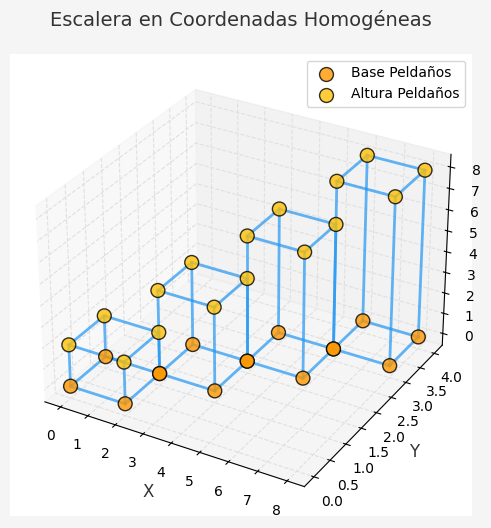

In [2]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider
%matplotlib inline

# Configurar estilo visual para gráficos
plt.style.use('default')  # Estilo limpio
plt.rcParams['figure.facecolor'] = '#F5F5F5'  # Fondo gris claro
plt.rcParams['axes.facecolor'] = '#FFFFFF'  # Fondo blanco en los ejes
plt.rcParams['grid.color'] = '#E0E0E0'  # Cuadrícula gris clara
plt.rcParams['grid.linestyle'] = '--'

# Generar puntos 3D de una escalera con 4 peldaños
puntos_3d = np.array([
    [0, 0, 0], [2, 0, 0], [2, 1, 0], [0, 1, 0],  # Peldaño 1 (base)
    [2, 1, 0], [4, 1, 0], [4, 2, 0], [2, 2, 0],  # Peldaño 2
    [4, 2, 0], [6, 2, 0], [6, 3, 0], [4, 3, 0],  # Peldaño 3
    [6, 3, 0], [8, 3, 0], [8, 4, 0], [6, 4, 0],  # Peldaño 4
    [0, 0, 2], [2, 0, 2], [2, 1, 2], [0, 1, 2],  # Altura peldaño 1
    [2, 1, 4], [4, 1, 4], [4, 2, 4], [2, 2, 4],  # Altura peldaño 2
    [4, 2, 6], [6, 2, 6], [6, 3, 6], [4, 3, 6],  # Altura peldaño 3
    [6, 3, 8], [8, 3, 8], [8, 4, 8], [6, 4, 8]   # Altura peldaño 4
]).T

# Convertir a coordenadas homogéneas (agregar w=1)
puntos_hom_3d = np.vstack((puntos_3d, np.ones((1, puntos_3d.shape[1]))))

# Definir aristas de la escalera
aristas = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # Peldaño 1 base
    (4, 5), (5, 6), (6, 7), (7, 4),  # Peldaño 2 base
    (8, 9), (9, 10), (10, 11), (11, 8),  # Peldaño 3 base
    (12, 13), (13, 14), (14, 15), (15, 12),  # Peldaño 4 base
    (16, 17), (17, 18), (18, 19), (19, 16),  # Peldaño 1 altura
    (20, 21), (21, 22), (22, 23), (23, 20),  # Peldaño 2 altura
    (24, 25), (25, 26), (26, 27), (27, 24),  # Peldaño 3 altura
    (28, 29), (29, 30), (30, 31), (31, 28),  # Peldaño 4 altura
    (0, 16), (1, 17), (2, 18), (3, 19),  # Conexiones altura peldaño 1
    (4, 20), (5, 21), (6, 22), (7, 23),  # Conexiones altura peldaño 2
    (8, 24), (9, 25), (10, 26), (11, 27),  # Conexiones altura peldaño 3
    (12, 28), (13, 29), (14, 30), (15, 31)  # Conexiones altura peldaño 4
]

# Visualizar la escalera en 3D con estilo mejorado
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# Peldaños base
ax.scatter(puntos_hom_3d[0, :16], puntos_hom_3d[1, :16], puntos_hom_3d[2, :16], c='#FF9800', s=100, label='Base Peldaños', edgecolor='black', alpha=0.8)  # Naranja
# Peldaños altura
ax.scatter(puntos_hom_3d[0, 16:], puntos_hom_3d[1, 16:], puntos_hom_3d[2, 16:], c='#FFC107', s=100, label='Altura Peldaños', edgecolor='black', alpha=0.8)  # Amarillo
for arista in aristas:
    x = [puntos_hom_3d[0, arista[0]], puntos_hom_3d[0, arista[1]]]
    y = [puntos_hom_3d[1, arista[0]], puntos_hom_3d[1, arista[1]]]
    z = [puntos_hom_3d[2, arista[0]], puntos_hom_3d[2, arista[1]]]
    ax.plot(x, y, z, c='#2196F3', lw=2, alpha=0.7)  # Azul
ax.set_title('Escalera en Coordenadas Homogéneas', fontsize=14, pad=20, color='#333333')
ax.set_xlabel('X', fontsize=12, color='#333333')
ax.set_ylabel('Y', fontsize=12, color='#333333')
ax.set_zlabel('Z', fontsize=12, color='#333333')
ax.grid(True)
ax.legend(fontsize=10)
plt.show()

## 2. Proyección Ortogonal
**La proyección ortogonal** elimina la coordenada <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>z</mi></mrow><annotation encoding="application/x-tex"> z </annotation></semantics></math>, proyectando los puntos 3D en el plano <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>x</mi><mi>y</mi></mrow><annotation encoding="application/x-tex"> xy </annotation></semantics></math>. Esto simula una cámara que no considera la profundidad, haciendo que todos los objetos aparezcan del mismo tamaño, independientemente de su distancia.

## Matriz de Proyección
La matriz de proyección ortogonal es:

\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}

Proceso

1. Convertimos los puntos 3D a coordenadas homogéneas (agregando <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>w</mi><mo>=</mo><mn>1</mn></mrow><annotation encoding="application/x-tex"> w=1 </annotation></semantics></math>).
2. Aplicamos la matriz de proyección.
3. Extraemos las coordenadas <math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>x</mi><mo separator="true">,</mo><mi>y</mi></mrow><annotation encoding="application/x-tex"> x, y </annotation></semantics></math> del resultado.
4. Visualizamos la proyección en 2D.

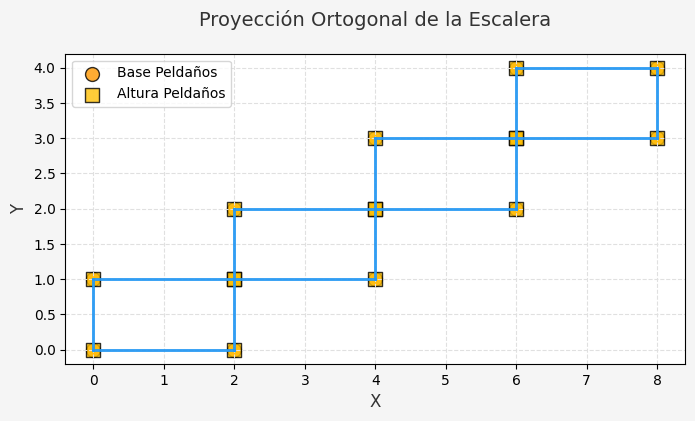

In [3]:
def proyectar_ortogonal_homogeneas(puntos_hom):
    """
    Aplica una proyección ortogonal a puntos en coordenadas homogéneas.
    puntos_hom: array de forma (4, N) con coordenadas (x, y, z, w)
    Retorna: coordenadas 2D (x, y)
    """
    P = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1]
    ])
    proy = P @ puntos_hom
    return proy[:-2, :]  # Devolver solo (x, y)

# Aplicar proyección ortogonal
puntos_ort = proyectar_ortogonal_homogeneas(puntos_hom_3d)

# Visualizar proyección ortogonal con estilo mejorado
plt.figure(figsize=(8, 6))
plt.scatter(puntos_ort[0, :16], puntos_ort[1, :16], c='#FF9800', s=100, marker='o', label='Base Peldaños', edgecolor='black', alpha=0.8)  # Naranja
plt.scatter(puntos_ort[0, 16:], puntos_ort[1, 16:], c='#FFC107', s=100, marker='s', label='Altura Peldaños', edgecolor='black', alpha=0.8)  # Amarillo
for arista in aristas:
    x = [puntos_ort[0, arista[0]], puntos_ort[0, arista[1]]]
    y = [puntos_ort[1, arista[0]], puntos_ort[1, arista[1]]]
    plt.plot(x, y, c='#2196F3', lw=2, alpha=0.7)  # Azul
plt.title('Proyección Ortogonal de la Escalera', fontsize=14, pad=20, color='#333333')
plt.xlabel('X', fontsize=12, color='#333333')
plt.ylabel('Y', fontsize=12, color='#333333')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(fontsize=10)
plt.show()

## 3. Proyección Perspectiva
La proyección perspectiva simula una cámara real, donde los objetos más lejanos aparecen más pequeños. Usamos una matriz de proyección que divide las coordenadas \(x\) y \(y\) por \(z/d\), donde \(d\) es la distancia focal.

## Matriz de Proyección

La matriz de proyección perspectiva es:
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & \frac{1}{d} & 0
\end{bmatrix}

## Efecto de \(d\)

- *d* pequeño (ej. 0.5): Mayor distorsión, similar a un lente gran angular.
- *d* grande (ej. 2.0): Menor distorsión, similar a un teleobjetivo.

## Proceso

1. Convertimos los puntos 3D a coordenadas homogéneas.
2. Aplicamos la matriz de proyección con un valor de *d*.
3. Normalizamos dividiendo por la coordenada *w*.
4. Visualizamos la proyección en 2D.

<ipython-input-8-dc4211ca69f6>:15: RuntimeWarning: divide by zero encountered in divide
  proy /= proy[-1, :]  # Normalizar por la coordenada w
<ipython-input-8-dc4211ca69f6>:15: RuntimeWarning: invalid value encountered in divide
  proy /= proy[-1, :]  # Normalizar por la coordenada w


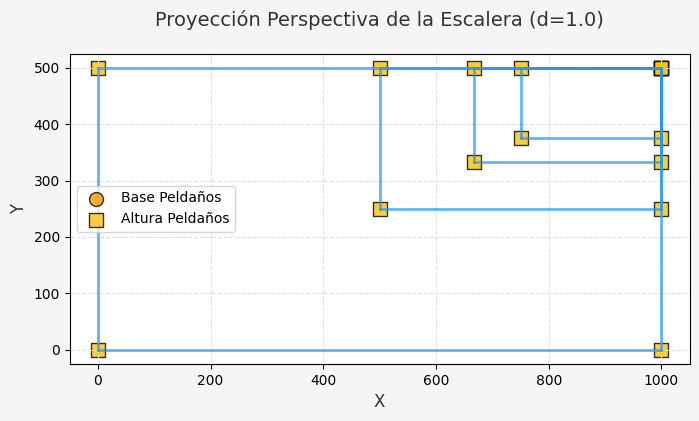

In [8]:
def proyectar_perspectiva_homogeneas(puntos_hom, d=1.0):
    """
    Aplica una proyección perspectiva a puntos en coordenadas homogéneas.
    puntos_hom: array de forma (4, N) con coordenadas (x, y, z, w)
    d: distancia focal
    Retorna: coordenadas 2D (x, y)
    """
    P = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1/d, 0]
    ])
    proy = P @ puntos_hom
    proy /= proy[-1, :]  # Normalizar por la coordenada w
    return proy[:-2, :]  # Devolver solo (x, y)

# Aplicar proyección perspectiva con d=1.0
puntos_per = proyectar_perspectiva_homogeneas(puntos_hom_3d, d=1000.0)

# Visualizar proyección perspectiva con estilo mejorado
plt.figure(figsize=(8, 6))
plt.scatter(puntos_per[0, :16], puntos_per[1, :16], c='#FF9800', s=100, marker='o', label='Base Peldaños', edgecolor='black', alpha=0.8)  # Naranja
plt.scatter(puntos_per[0, 16:], puntos_per[1, 16:], c='#FFC107', s=100, marker='s', label='Altura Peldaños', edgecolor='black', alpha=0.8)  # Amarillo
for arista in aristas:
    x = [puntos_per[0, arista[0]], puntos_per[0, arista[1]]]
    y = [puntos_per[1, arista[0]], puntos_per[1, arista[1]]]
    plt.plot(x, y, c='#2196F3', lw=2, alpha=0.7)  # Azul
plt.title('Proyección Perspectiva de la Escalera (d=1.0)', fontsize=14, pad=20, color='#333333')
plt.xlabel('X', fontsize=12, color='#333333')
plt.ylabel('Y', fontsize=12, color='#333333')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(fontsize=10)
plt.show()

## 4. Ajuste Interactivo de la Distancia Focal

Para explorar cómo la distancia focal *d* afecta la proyección perspectiva, usamos un slider interactivo con `ipywidgets`. Esto permite ajustar *d* en tiempo real y visualizar el efecto en la proyección del cubo.

## Detalles

- **Interactividad:** Cada cambio en el slider actualiza la proyección y la muestra en un gráfico 2D.
- **Ventaja:** Similar a los sliders del ejemplo, esta herramienta permite experimentar con los parámetros de forma dinámica, sin necesidad de modificar el código.

In [9]:
# Función para aplicar y visualizar la proyección perspectiva con un valor de d
def visualizar_perspectiva(d, ax):
    try:
        # Aplicar proyección perspectiva usando coordenadas homogéneas
        puntos_per = proyectar_perspectiva_homogeneas(puntos_hom_3d, d=d)

        # Plot on the provided ax with improved style
        ax.scatter(puntos_per[0, :16], puntos_per[1, :16], c='#FF9800', s=100, marker='o', label='Base Peldaños', edgecolor='black', alpha=0.8)  # Naranja
        ax.scatter(puntos_per[0, 16:], puntos_per[1, 16:], c='#FFC107', s=100, marker='s', label='Altura Peldaños', edgecolor='black', alpha=0.8)  # Amarillo
        for arista in aristas:
            x = [puntos_per[0, arista[0]], puntos_per[0, arista[1]]]
            y = [puntos_per[1, arista[0]], puntos_per[1, arista[1]]]
            ax.plot(x, y, c='#2196F3', lw=2, alpha=0.7)  # Azul
        ax.set_title(f'Proyección Perspectiva (d={d:.2f})', fontsize=12, pad=15, color='#333333')
        ax.set_xlabel('X', fontsize=10, color='#333333')
        ax.set_ylabel('Y', fontsize=10, color='#333333')
        ax.set_xlim(0, 8)  # Forzar límites
        ax.set_ylim(0, 4)
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')
        ax.legend(fontsize=8)
    except Exception as e:
        print(f"Error al visualizar la proyección: {e}")

# Crear una nueva figura para el slider interactivo
def visualizar_interactivo(d):
    fig, ax = plt.subplots(figsize=(6, 4))  # Crear una figura y eje nuevos
    visualizar_perspectiva(d, ax)  # Llamar a la función con el eje
    plt.show()

# Crear slider interactivo
interact(visualizar_interactivo,
         d=FloatSlider(min=0.5, max=12.0, step=0.05, value=1.0, description='Distancia Focal (d)'))

interactive(children=(FloatSlider(value=1.0, description='Distancia Focal (d)', max=12.0, min=0.5, step=0.05),…

<function __main__.visualizar_interactivo(d)>

## 5. Comparación Gráfica de Proyecciones

Finalmente, generamos una figura que compara:

El cubo original en 3D.
La proyección ortogonal.
Proyecciones perspectiva con tres distancias focales \(d = 2.0, 7.0, 10.0\):

##Detalles

* Disposición: Cinco subgráficos en una cuadrícula 2x3.
* Guardado: La figura se guarda como `proyecciones.png` para su uso en el `README.md`.
* Uso en el entregable: Incluye la figura en el `README.md` con una descripción de las diferencias entre las proyecciones.

<ipython-input-8-dc4211ca69f6>:15: RuntimeWarning: divide by zero encountered in divide
  proy /= proy[-1, :]  # Normalizar por la coordenada w
<ipython-input-8-dc4211ca69f6>:15: RuntimeWarning: invalid value encountered in divide
  proy /= proy[-1, :]  # Normalizar por la coordenada w


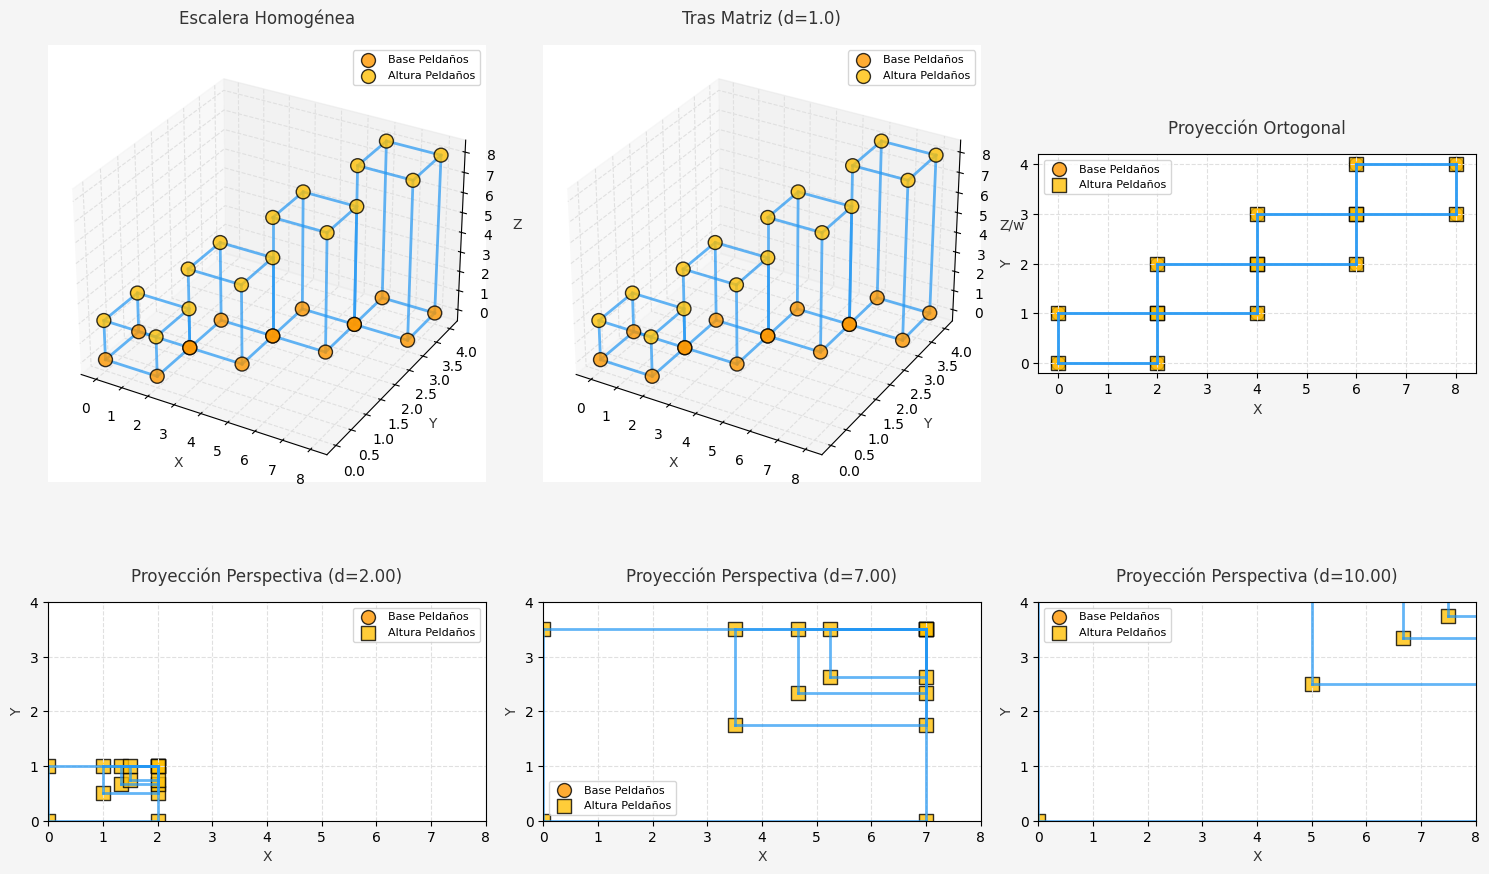

In [10]:
# Crear figura con comparaciones
fig = plt.figure(figsize=(15, 10))

# 1. Puntos 3D en Coordenadas Homogéneas
ax1 = fig.add_subplot(231, projection='3d')
ax1.scatter(puntos_hom_3d[0, :16], puntos_hom_3d[1, :16], puntos_hom_3d[2, :16], c='#FF9800', s=100, label='Base Peldaños', edgecolor='black', alpha=0.8)  # Naranja
ax1.scatter(puntos_hom_3d[0, 16:], puntos_hom_3d[1, 16:], puntos_hom_3d[2, 16:], c='#FFC107', s=100, label='Altura Peldaños', edgecolor='black', alpha=0.8)  # Amarillo
for arista in aristas:
    x = [puntos_hom_3d[0, arista[0]], puntos_hom_3d[0, arista[1]]]
    y = [puntos_hom_3d[1, arista[0]], puntos_hom_3d[1, arista[1]]]
    z = [puntos_hom_3d[2, arista[0]], puntos_hom_3d[2, arista[1]]]
    ax1.plot(x, y, z, c='#2196F3', lw=2, alpha=0.7)  # Azul
ax1.set_title('Escalera Homogénea', fontsize=12, pad=15, color='#333333')
ax1.set_xlabel('X', fontsize=10, color='#333333')
ax1.set_ylabel('Y', fontsize=10, color='#333333')
ax1.set_zlabel('Z', fontsize=10, color='#333333')
ax1.grid(True)
ax1.legend(fontsize=8)

# 2. Transformación Intermedia (Perspectiva, d=1.0)
d = 1.0
P_persp = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 1/d, 0]
])
puntos_proy_hom = P_persp @ puntos_hom_3d
ax2 = fig.add_subplot(232, projection='3d')
ax2.scatter(puntos_proy_hom[0, :16], puntos_proy_hom[1, :16], puntos_proy_hom[2, :16], c='#FF9800', s=100, label='Base Peldaños', edgecolor='black', alpha=0.8)
ax2.scatter(puntos_proy_hom[0, 16:], puntos_proy_hom[1, 16:], puntos_proy_hom[2, 16:], c='#FFC107', s=100, label='Altura Peldaños', edgecolor='black', alpha=0.8)
for arista in aristas:
    x = [puntos_proy_hom[0, arista[0]], puntos_proy_hom[0, arista[1]]]
    y = [puntos_proy_hom[1, arista[0]], puntos_proy_hom[1, arista[1]]]
    z = [puntos_proy_hom[2, arista[0]], puntos_proy_hom[2, arista[1]]]
    ax2.plot(x, y, z, c='#2196F3', lw=2, alpha=0.7)
ax2.set_title('Tras Matriz (d=1.0)', fontsize=12, pad=15, color='#333333')
ax2.set_xlabel('X', fontsize=10, color='#333333')
ax2.set_ylabel('Y', fontsize=10, color='#333333')
ax2.set_zlabel('Z/w', fontsize=10, color='#333333')
ax2.grid(True)
ax2.legend(fontsize=8)

# 3. Proyección Ortogonal
puntos_ort = proyectar_ortogonal_homogeneas(puntos_hom_3d)
ax3 = fig.add_subplot(233)
ax3.scatter(puntos_ort[0, :16], puntos_ort[1, :16], c='#FF9800', s=100, marker='o', label='Base Peldaños', edgecolor='black', alpha=0.8)
ax3.scatter(puntos_ort[0, 16:], puntos_ort[1, 16:], c='#FFC107', s=100, marker='s', label='Altura Peldaños', edgecolor='black', alpha=0.8)
for arista in aristas:
    x = [puntos_ort[0, arista[0]], puntos_ort[0, arista[1]]]
    y = [puntos_ort[1, arista[0]], puntos_ort[1, arista[1]]]
    ax3.plot(x, y, c='#2196F3', lw=2, alpha=0.7)
ax3.set_title('Proyección Ortogonal', fontsize=12, pad=15, color='#333333')
ax3.set_xlabel('X', fontsize=10, color='#333333')
ax3.set_ylabel('Y', fontsize=10, color='#333333')
ax3.grid(True)
ax3.set_aspect('equal', adjustable='box')
ax3.legend(fontsize=8)

# 4-5. Proyecciones Perspectiva con diferentes distancias focales
distancias = [2.0, 7.0, 10.0]
for i, d in enumerate(distancias):
    ax = fig.add_subplot(2, 3, i + 4)  # Segunda fila: 4, 5, 6
    visualizar_perspectiva(d, ax)  # Pass ax to the function

plt.tight_layout()
plt.savefig('proyecciones_escalera.png')
plt.show()